In [19]:
import pandas as pd
import numpy as np
from dowhy import CausalModel
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from econml.dml import CausalForestDML
from econml.dr import DRLearner
import matplotlib.pyplot as plt
from dowhy import CausalModel, gcm
import seaborn as sns
import scipy.stats as stats
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler


In [20]:
df = pd.read_csv("alerts_with_category_with_apk_size_updated.csv")
print("Original rows:", len(df))

df = df[~df["code_location"].str.contains("obfuscated", case=False, na=False)].copy()
print("After removing obfuscated:", len(df))

df["verdict"] = df["verdict"].astype(int)

download_order = ['<100','100-500','500-1k','1k-5k','5k-10k','10k-50k','50k-100k','100k-500k','500k-1M','1M-5M','>5M']
ord_map = {c: i for i, c in enumerate(download_order)}
df["app_popularity_encoded"] = df["app_popularity"].map(ord_map)

df = df.dropna(subset=["app_popularity_encoded"]).copy()
df["app_popularity_encoded"] = df["app_popularity_encoded"].astype(int)

scaler = RobustScaler()
df["apk_size_scaled"] = scaler.fit_transform(df[["apk_size"]])

print("\nValue counts for code_location:")
print(df["code_location"].value_counts())


Original rows: 6140
After removing obfuscated: 5612

Value counts for code_location:
code_location
Utilities            3039
others               1341
developer_written     511
Android               494
SocialMedia           180
Analytics              34
Cloud                  13
Name: count, dtype: int64


In [21]:
df.head()

,alert_description,verdict,artifact_location,app_package_name,version_code,app_popularity,sast_tool_name,code_location,3rd_party_library_name,apk_size,app_popularity_encoded,apk_size_scaled
0,"Constraint ""algorithm in {SHA-256, SHA-384, SH...",1,com/applovin/impl/sdk/utils/m.java,all.language.translator.hub.malayalamtosamoant...,1,<100,CogniCrypt,others,unknown,14562465,0,0.015672
1,"Constraint ""algorithm in {SHA-256, SHA-384, SH...",1,com/applovin/impl/sdk/utils/StringUtils.java,all.language.translator.hub.malayalamtosamoant...,1,<100,CogniCrypt,others,unknown,14562465,0,0.015672
2,"Constraint ""algorithm in {SHA-256, SHA-384, SH...",1,com/google/android/gms/internal/ads/zzcgg.java,all.language.translator.hub.malayalamtosamoant...,1,<100,CogniCrypt,Android,com.google.android.gms::play-services-ads-base,14562465,0,0.015672
3,"Constraint ""algorithm in {SHA-256, SHA-384, SH...",1,com/google/android/gms/internal/ads/zzcgg.java,all.language.translator.hub.malayalamtosamoant...,1,<100,CogniCrypt,Android,com.google.android.gms::play-services-ads-base,14562465,0,0.015672
4,"Constraint ""algorithm in {SHA-256, SHA-384, SH...",1,com/google/android/gms/internal/zzaiy.java,aplus.droitfiscal,37,5k-10k,CogniCrypt,Android,com.google.android.gms::play-services-clearcut,3041670,4,-0.674171


In [22]:
def make_pairwise_balanced(df, lib_name, baseline):
    df_sub = df[df["lib_grouped"].isin([baseline, lib_name])].copy()

    base = df_sub[df_sub["lib_grouped"] == baseline]
    lib  = df_sub[df_sub["lib_grouped"] == lib_name]

    n_min = min(len(base), len(lib))

    base_bal = base.sample(n=n_min, replace=False, random_state=42)
    lib_bal  = lib.sample(n=n_min, replace=False, random_state=42)

    df_balanced_pair = pd.concat([base_bal, lib_bal])
    df_balanced_pair = df_balanced_pair.sample(frac=1, random_state=42).reset_index(drop=True)
    print(f"\nBalanced pair: {baseline} vs {lib_name}")
    print(df_balanced_pair["lib_grouped"].value_counts())

    return df_balanced_pair

In [23]:
small_libs = ["SocialMedia", "Analytics", "Cloud"]
df["lib_grouped"] = df["code_location"].replace(small_libs, "Small_Libraries")

df.loc[df["lib_grouped"] == "developer_written", "lib_grouped"] = "App_Source_Code"

print("\nGrouped library counts:")
print(df["lib_grouped"].value_counts())

libs = list(df["lib_grouped"].unique())
libs = ["App_Source_Code"] + [l for l in libs if l != "App_Source_Code"]

print("\nTreatment levels (library types):")
for name in libs:
    print("-", name)



Grouped library counts:
lib_grouped
Utilities          3039
others             1341
App_Source_Code     511
Android             494
Small_Libraries     227
Name: count, dtype: int64

Treatment levels (library types):
- App_Source_Code
- others
- Android
- Utilities
- Small_Libraries


In [24]:
df.head()

,alert_description,verdict,artifact_location,app_package_name,version_code,app_popularity,sast_tool_name,code_location,3rd_party_library_name,apk_size,app_popularity_encoded,apk_size_scaled,lib_grouped
0,"Constraint ""algorithm in {SHA-256, SHA-384, SH...",1,com/applovin/impl/sdk/utils/m.java,all.language.translator.hub.malayalamtosamoant...,1,<100,CogniCrypt,others,unknown,14562465,0,0.015672,others
1,"Constraint ""algorithm in {SHA-256, SHA-384, SH...",1,com/applovin/impl/sdk/utils/StringUtils.java,all.language.translator.hub.malayalamtosamoant...,1,<100,CogniCrypt,others,unknown,14562465,0,0.015672,others
2,"Constraint ""algorithm in {SHA-256, SHA-384, SH...",1,com/google/android/gms/internal/ads/zzcgg.java,all.language.translator.hub.malayalamtosamoant...,1,<100,CogniCrypt,Android,com.google.android.gms::play-services-ads-base,14562465,0,0.015672,Android
3,"Constraint ""algorithm in {SHA-256, SHA-384, SH...",1,com/google/android/gms/internal/ads/zzcgg.java,all.language.translator.hub.malayalamtosamoant...,1,<100,CogniCrypt,Android,com.google.android.gms::play-services-ads-base,14562465,0,0.015672,Android
4,"Constraint ""algorithm in {SHA-256, SHA-384, SH...",1,com/google/android/gms/internal/zzaiy.java,aplus.droitfiscal,37,5k-10k,CogniCrypt,Android,com.google.android.gms::play-services-clearcut,3041670,4,-0.674171,Android


In [ ]:
def fit_drl_for_library(df_full, lib_name, baseline):
   
    df_sub = df_full[df_full["lib_grouped"].isin([baseline, lib_name])].copy()
    counts = df_sub["lib_grouped"].value_counts()    

    print(f"\n=== Library: {lib_name} vs {baseline} ===")
    print("Counts:", counts.to_dict())

    Y = df_sub["verdict"].values

    T = (df_sub["lib_grouped"] == lib_name).astype(int).values
    W = df_sub[["app_popularity_encoded"]].values
    X = df_sub[["app_popularity_encoded"]].values

    dr = DRLearner(
        model_regression=RandomForestRegressor(
            n_estimators=300,
            min_samples_leaf=10,
            # random_state=42
        ),
        model_propensity=RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=10,
            # random_state=42
        ),
        model_final=RandomForestRegressor(
            n_estimators=300,
            min_samples_leaf=10,
            # random_state=42
        ),
        random_state=42
    )

    dr.fit(Y, T, X=X, W=W)
    print("  -> -> DRLearner fitted.")

    tau_hat = dr.effect(X)
    ate = float(np.mean(tau_hat))
    ate_std = float(np.std(tau_hat))

    result = {
        "library": lib_name,
        "n_baseline": int(counts[baseline]),
        "n_treated": int(counts[lib_name]),
        "third_party_lib_vs_baseline": ate,
        "ATE_tau_std": ate_std,
    }

    print("  DRLearner ATE (lib vs baseline):", ate)
    print("  Std of CATE across alerts:", ate_std)
    
    return result



In [26]:
results = []
baseline_name = "App_Source_Code"

for lib in libs:
    if lib == baseline_name:
        continue
    
    df_balanced = make_pairwise_balanced(df, lib, baseline=baseline_name)
    res = fit_drl_for_library(df_balanced, lib, baseline_name)
    if res is not None:
        results.append(res)

results_df = pd.DataFrame(results).sort_values("third_party_lib_vs_baseline")
print("\n\n===== Summary: Causal effect of each library vs App_Source_Code =====")
print(results_df)



Balanced pair: App_Source_Code vs others
lib_grouped
others             511
App_Source_Code    511
Name: count, dtype: int64

=== Library: others vs App_Source_Code ===
Counts: {'others': 511, 'App_Source_Code': 511}
[1 0 1 ... 1 0 0]
  -> -> DRLearner fitted.
  DRLearner ATE (lib vs baseline): -0.10683849584743851
  Std of CATE across alerts: 0.2070511377570279

Balanced pair: App_Source_Code vs Android
lib_grouped
App_Source_Code    494
Android            494
Name: count, dtype: int64

=== Library: Android vs App_Source_Code ===
Counts: {'App_Source_Code': 494, 'Android': 494}
[0 0 1 0 0 1 0 0 0 1 0 0 0 0 1 1 1 1 0 1 0 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 0
 1 1 1 1 0 0 1 0 0 1 1 1 0 0 0 1 0 0 1 1 0 0 1 0 0 1 0 0 0 1 1 1 0 0 0 1 0
 0 0 1 1 0 1 0 0 0 1 0 1 1 1 0 1 0 1 0 1 1 1 0 1 0 1 1 0 1 1 1 0 1 0 0 0 1
 0 1 1 1 1 0 1 1 0 0 0 0 1 0 1 1 1 1 1 1 0 1 0 0 1 0 1 1 1 0 0 0 1 0 1 1 1
 0 0 1 0 0 0 0 0 1 1 0 0 1 0 1 1 1 0 0 0 0 0 1 1 1 1 1 1 1 1 1 0 0 1 1 0 1
 0 1 0 0 0 0 1 1 0 1 0 1 0 1 0 0 0 1 0

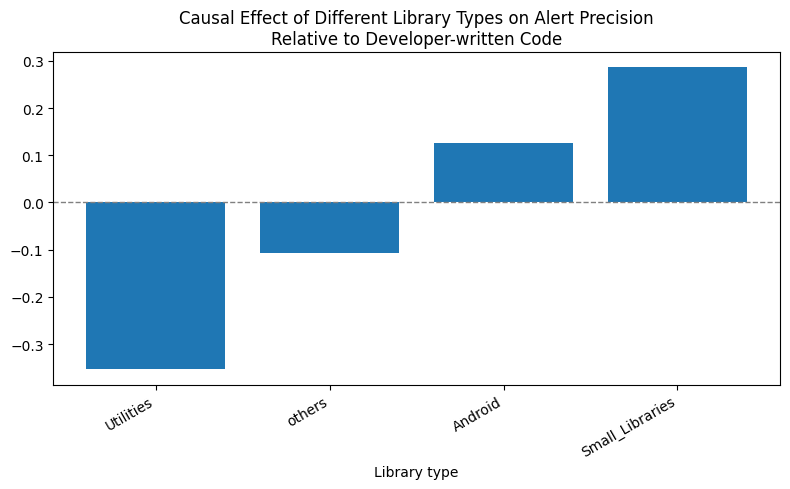

In [27]:
plot_df = results_df.sort_values("third_party_lib_vs_baseline").copy()

x = np.arange(len(plot_df)) 
y = plot_df["third_party_lib_vs_baseline"].values
yerr = plot_df["ATE_tau_std"].values  

plt.figure(figsize=(8, 5))
plt.bar(x, y)
plt.axhline(0, color="gray", linestyle="--", linewidth=1)

plt.xticks(x, plot_df["library"], rotation=30, ha="right")
plt.ylabel("")
plt.xlabel("Library type")
plt.title("Causal Effect of Different Library Types on Alert Precision\nRelative to Developer-written Code")

plt.tight_layout()
plt.show()
